# School Enrolment Trends Data Visualisation Analysis Project

Authored by: Hanwen Dun   
Duration: 90 mins   
Level: Intermediate   
Pre-requisite Skills: Python, pandas, matplotlib, seaborn, basic statistics   

## Objective

The goal of this use case is to analyse school enrolment trends using a real-world education dataset. This involves examining how student numbers change over time, comparing enrolment across different regions or school types, and visualising these trends using data visualisation techniques.

Through this analysis, we aim to identify patterns in school enrolment that can help education planners understand student demand and support better resource allocation in the education system.

## Scenario

In this scenario, you take on the role of a data analyst working for an education department or school administration authority.

Your task is to analyse school enrolment data to answer several important questions related to education planning and student population trends.

Specifically, you aim to understand:

1. How student enrolment has changed over time.

2. Which regions have the highest or lowest enrolment numbers.

3. Whether enrolment patterns differ between different school types.

4. How enrolment trends may develop in the future.

By analysing these patterns, decision makers can better plan school infrastructure, allocate teachers, and manage education resources effectively.

## What this use case will teach you

### At the end of this use case you will:

This use case provides hands-on experience in processing, cleaning, and analysing education data. You will gain insights in:

1. Data Cleaning and Preparation  
Learn how to clean and preprocess education datasets using pandas, including handling missing values and formatting data correctly.

2. Trend Analysis  
Analyse how school enrolment changes across different years and identify long-term trends in student numbers.

3. Regional Comparison  
Compare enrolment patterns across different geographic regions or school categories.

4. Data Visualisation  
Use visualisation tools such as matplotlib and seaborn to create charts that clearly communicate data insights.

5. Basic Predictive Insights  
Explore simple techniques to estimate future enrolment trends based on historical data.

## Importing Required Libraries

In [13]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
import folium
from IPython.display import Image, display
from folium.plugins import MarkerCluster
from IPython.display import display, clear_output
from io import StringIO
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from IPython.display import IFrame


## Importing the required dataset

### Purpose of This Section

This section imports the required school enrolment and school location datasets for the project. The datasets include four years of enrolment data from 2022 to 2025, as well as school location information across Victoria.

### Why This Step Was Conducted

Importing these datasets is the foundation of the analysis. The enrolment datasets allow trends over time to be examined, while the school location dataset provides geographic information such as coordinates and LGA names. Combining these data sources enables further visualisation, clustering, spatial analysis, and forecasting.

In [19]:
# Import the school locations data set using API
base_url = "https://discover.data.vic.gov.au/api/3/action/datastore_search"

resource_id = "a70cb615-ed28-48b6-bebe-2d0d346f7927"

url = f"{base_url}?resource_id={resource_id}&limit=5000"

response = requests.get(url)

if response.status_code == 200:

    data = response.json()

    school_locations_df = pd.DataFrame(data["result"]["records"])

    print(school_locations_df.head())

else:

    print(f"Request failed with status code {response.status_code}")

   _id Education_Sector Entity_Type School_No                    School_Name  \
0    1         Catholic           2        20                 Parade College   
1    2         Catholic           2        25       Simonds Catholic College   
2    3         Catholic           2        26    St Mary’s College Melbourne   
3    4         Catholic           2        28  St Patrick's College Ballarat   
4    5         Catholic           2        29            St Patrick's School   

  School_Type             Address_Line_1 Address_Line_2    Address_Town  \
0   Secondary           1436 Plenty Road           None        BUNDOORA   
1   Secondary        273 Victoria Street           None  WEST MELBOURNE   
2   Secondary         11 Westbury Street           None   ST KILDA EAST   
3   Secondary          1431 Sturt Street           None        BALLARAT   
4     Primary  119 Drummond Street South           None        BALLARAT   

  Address_State  ...     Postal_Town Postal_State Postal_Postcode  \

In [20]:
# load the enrolment data for 2022 to 2025 from the GitHub repo)
files = {
    "dv335-allschoolsFTEenrolmentsFeb2022.csv": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv335-allschoolsFTEenrolmentsFeb2022.csv",
    "dv355-VIC All Schools Enrolments 2023.csv": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv355-VIC%20All%20Schools%20Enrolments%202023.csv",
    "dv377_DataVic-AllSchoolsEnrolments-2024.csv": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv377_DataVic-AllSchoolsEnrolments-2024.csv",
    "dv403-AllSchoolsEnrolments-2025.csv": "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00206_Project%2035_Source%20Data/dv403-AllSchoolsEnrolments-2025.csv",
}

dfs = []
for fname, url in files.items():
    df = pd.read_csv(url, encoding="latin1")
    df.columns = (
        df.columns
        .str.strip()
        .str.replace('"', '', regex=False)
        .str.replace(' ', '_')
    )
    df["School_No"] = df["School_No"].astype(str).str.strip()
    # Assign Census_Year based on filename
    if "2022" in fname:
        df["Census_Year"] = 2022
    elif "2023" in fname:
        df["Census_Year"] = 2023
    elif "2024" in fname:
        df["Census_Year"] = 2024
    elif "2025" in fname:
        df["Census_Year"] = 2025
    dfs.append(df)

enrolments_all_df = pd.concat(dfs, ignore_index=True)
print(enrolments_all_df.shape)
print(enrolments_all_df.head())


(9172, 34)
  Education_Sector  Entity_Type School_No                  School_Name  \
0         Catholic            2       204           St Monica's School   
1         Catholic            2       205           St Joseph's School   
2         Catholic            2       212  St Brendan's Primary School   
3         Catholic            2       219         Sacred Heart College   
4         Catholic            2       227          St Patrick's School   

  School_Type School_Status  Prep_Total  Year_1_Total  Year_2_Total  \
0     Primary             O        47.0          34.0          58.0   
1     Primary             O        52.0          55.0          42.0   
2     Primary             O         1.0           2.0           3.0   
3   Secondary             O         0.0           0.0           0.0   
4     Primary             O        17.0          23.0          21.0   

   Year_3_Total  ...  Year  CENSUS_TYPE  Census_Year  DE_Admin_Region  \
0          55.0  ...  2022            F     

In [21]:
# Find common columns

# Get columns from each DataFrame as a set
columns_sets = [set(df.columns) for df in dfs]

# common columns
common_columns = list(set.intersection(*columns_sets))  # convert set to list
print("Common columns in all 4 files:")
print(common_columns)

Common columns in all 4 files:
['Year', 'School_Status', 'Secondary_Total', 'Secondary_Ungraded_Total', 'Year_5_Total', 'School_No', 'Year_2_Total', 'Year_7_Total', 'Primary_Total', 'Year_10_Total', 'Census_Year', 'Year_3_Total', 'Year_9_Total', 'Year_6_Total', 'Year_8_Total', 'Entity_Type', 'Year_12_Total', 'Grand_Total', 'Year_1_Total', 'Year_4_Total', 'School_Name', 'Prep_Total', 'Primary_Ungraded_Total', 'CENSUS_TYPE', 'School_Type', 'Year_11_Total']


In [22]:
#Filter common columns
enrolments_all_df = pd.concat([df[common_columns] for df in dfs], ignore_index=True)
print(enrolments_all_df.shape)
print(enrolments_all_df.head(5))

(9172, 26)
   Year School_Status  Secondary_Total  Secondary_Ungraded_Total  \
0  2022             O              0.0                       0.0   
1  2022             O              0.0                       0.0   
2  2022             O              0.0                       0.0   
3  2022             O           1463.0                       0.0   
4  2022             O              0.0                       0.0   

   Year_5_Total School_No  Year_2_Total  Year_7_Total  Primary_Total  \
0          46.0       204          58.0           0.0          316.0   
1          46.0       205          42.0           0.0          351.0   
2           3.0       212           3.0           0.0           15.0   
3           0.0       219           0.0         237.0            0.0   
4          10.0       227          21.0           0.0          110.0   

   Year_10_Total  ...  Year_12_Total  Grand_Total  Year_1_Total  Year_4_Total  \
0            0.0  ...            0.0        316.0          34.0   

## Dataset preprocessing

### Purpose of This Section

This section prepares the imported datasets for analysis by cleaning the data, checking missing values, standardising column names, creating consistent identifiers, and merging enrolment data with school location information.

### Why This Step Was Conducted

Dataset preprocessing is necessary to ensure that the data is accurate, consistent, and suitable for analysis. Cleaning and standardising the datasets helps reduce errors, while merging them creates a complete dataset that links enrolment patterns with school locations. This provides a reliable foundation for trend analysis, regional comparison, clustering, mapping, and future prediction.

In [28]:
# Check unique School_No per Census_Year
for year in enrolments_all_df["Census_Year"].unique():
    df_year = enrolments_all_df[enrolments_all_df["Census_Year"] == year]
    total_schools = len(df_year)
    unique_schools = df_year["School_No"].nunique()
    print(f"Year {year}: Total rows = {total_schools}, Unique School_No = {unique_schools}")

Year 2022: Total rows = 2286, Unique School_No = 2145
Year 2023: Total rows = 2290, Unique School_No = 2149
Year 2024: Total rows = 2295, Unique School_No = 2155
Year 2025: Total rows = 2301, Unique School_No = 2162


In [29]:
# Check one example of duplicate School_No per year
for year in enrolments_all_df["Census_Year"].unique():
    df_year = enrolments_all_df[enrolments_all_df["Census_Year"] == year]
    
    # Find duplicated School_No
    duplicated_schools = df_year[df_year.duplicated(subset=["School_No"], keep=False)]
    
    if not duplicated_schools.empty:
        # Get the first duplicate School_No
        first_dup_school_no = duplicated_schools["School_No"].iloc[0]
        
        print(f"\nYear {year} - Example duplicate School_No: {first_dup_school_no}")
        print(duplicated_schools[duplicated_schools["School_No"] == first_dup_school_no])


Year 2022 - Example duplicate School_No: 250
     Year School_Status  Secondary_Total  Secondary_Ungraded_Total  \
6    2022             O           1209.0                       0.0   
492  2022             O              0.0                       0.0   

     Year_5_Total School_No  Year_2_Total  Year_7_Total  Primary_Total  \
6             0.0       250           0.0         203.0            0.0   
492          26.0       250          61.0           0.0          332.0   

     Year_10_Total  ...  Year_12_Total  Grand_Total  Year_1_Total  \
6            201.0  ...          194.0       1209.0           0.0   
492            0.0  ...            0.0        332.0          60.0   

     Year_4_Total                School_Name  Prep_Total  \
6             0.0    Star of the Sea College         0.0   
492          55.0  Flemington Primary School        63.0   

     Primary_Ungraded_Total  CENSUS_TYPE  School_Type  Year_11_Total  
6                       0.0            F    Secondary       

In [30]:
# Check unique Entity_Type values per year
entity_types_per_year = (
    enrolments_all_df.groupby("Census_Year")["Entity_Type"]
    .unique()
    .reset_index()
    .rename(columns={"Entity_Type": "Unique_Entity_Types"})
)

print(entity_types_per_year)

   Census_Year Unique_Entity_Types
0         2022              [2, 1]
1         2023              [2, 1]
2         2024              [2, 1]
3         2025              [2, 1]


In [31]:
# Create a unique school ID by prefixing based on Entity_Type
def create_unique_id(row):
    if row["Entity_Type"] == 1:
        return 100_000 + int(row["School_No"])
    elif row["Entity_Type"] == 2:
        return 200_000 + int(row["School_No"])
    else:
        return int(row["School_No"])  # fallback, just in case

enrolments_all_df["Unique_School_ID"] = enrolments_all_df.apply(create_unique_id, axis=1)

# Check the first few rows
print(enrolments_all_df[["School_No", "Entity_Type", "Unique_School_ID"]].head(10))

  School_No  Entity_Type  Unique_School_ID
0       204            2            200204
1       205            2            200205
2       212            2            200212
3       219            2            200219
4       227            2            200227
5       236            2            200236
6       250            2            200250
7       251            2            200251
8       252            2            200252
9       262            2            200262


In [32]:
# Count of schools by School_Status and Census_Year
status_counts = enrolments_all_df.groupby(["Census_Year", "School_Status"])["Unique_School_ID"].nunique().reset_index()

# Rename for clarity
status_counts.rename(columns={"Unique_School_ID": "School_Count"}, inplace=True)

print(status_counts)

   Census_Year School_Status  School_Count
0         2022             C             1
1         2022             O          2284
2         2022             U             1
3         2023             C             1
4         2023             O          2286
5         2023             U             3
6         2024             O          2294
7         2024             U             1
8         2025             C             4
9         2025             O          2297


In [33]:
# Keep only open schools
open_schools_df = enrolments_all_df[enrolments_all_df["School_Status"] == "O"]

# Count the number of years each school appears in the dataset
school_year_counts = open_schools_df.groupby("Unique_School_ID")["Census_Year"].nunique().reset_index()
school_year_counts.rename(columns={"Census_Year": "Year_Count"}, inplace=True)

# Keep only schools that appear in all 4 years
schools_all_years = school_year_counts[school_year_counts["Year_Count"] == 4]["Unique_School_ID"]

# Filter the open_schools_df
open_schools_all_years_df = open_schools_df[open_schools_df["Unique_School_ID"].isin(schools_all_years)]

# Check result
print(open_schools_all_years_df.groupby("Census_Year")["Unique_School_ID"].nunique())

Census_Year
2022    2246
2023    2246
2024    2246
2025    2246
Name: Unique_School_ID, dtype: int64


In [34]:
print(open_schools_all_years_df.shape)
open_schools_all_years_df.head()

(8984, 27)


,Year,School_Status,Secondary_Total,Secondary_Ungraded_Total,Year_5_Total,School_No,Year_2_Total,Year_7_Total,Primary_Total,Year_10_Total,...,Grand_Total,Year_1_Total,Year_4_Total,School_Name,Prep_Total,Primary_Ungraded_Total,CENSUS_TYPE,School_Type,Year_11_Total,Unique_School_ID
0,2022,O,0.0,0.0,46.0,204,58.0,0.0,316.0,0.0,...,316.0,34.0,39.0,St Monica's School,47.0,0.0,F,Primary,0.0,200204
1,2022,O,0.0,0.0,46.0,205,42.0,0.0,351.0,0.0,...,351.0,55.0,46.0,St Joseph's School,52.0,0.0,F,Primary,0.0,200205
3,2022,O,1463.0,0.0,0.0,219,0.0,237.0,0.0,235.0,...,1463.0,0.0,0.0,Sacred Heart College,0.0,0.0,F,Secondary,249.0,200219
4,2022,O,0.0,0.0,10.0,227,21.0,0.0,110.0,0.0,...,110.0,23.0,14.0,St Patrick's School,17.0,0.0,F,Primary,0.0,200227
5,2022,O,800.0,0.0,0.0,236,0.0,162.0,0.0,151.0,...,800.0,0.0,0.0,St Joseph's College Mildura,0.0,0.0,F,Secondary,109.0,200236


In [35]:
# Check unique School_No per Census_Year
for year in open_schools_all_years_df["Census_Year"].unique():
    df_year = open_schools_all_years_df[open_schools_all_years_df["Census_Year"] == year]
    total_schools = len(df_year)
    unique_schools = df_year["Unique_School_ID"].nunique()
    print(f"Year {year}: Total rows = {total_schools}, Unique School_No = {unique_schools}")

Year 2022: Total rows = 2246, Unique School_No = 2246
Year 2023: Total rows = 2246, Unique School_No = 2246
Year 2024: Total rows = 2246, Unique School_No = 2246
Year 2025: Total rows = 2246, Unique School_No = 2246


In [36]:
## lets create a similar unique ID for the location dataset

# Make a copy to avoid SettingWithCopyWarning
school_locations_df = school_locations_df.copy()

# Ensure Entity_Type_loc is integer
school_locations_df["Entity_Type"] = school_locations_df["Entity_Type"].astype(int)

# Create unique school ID
def create_unique_id_loc(row):
    if row["Entity_Type"] == 1:
        return 100_000 + int(row["School_No"])
    elif row["Entity_Type"] == 2:
        return 200_000 + int(row["School_No"])
    else:
        return int(row["School_No"])  # fallback

school_locations_df["Unique_School_ID"] = school_locations_df.apply(create_unique_id_loc, axis=1)

# Check
print(school_locations_df.shape)
print(school_locations_df[["School_No", "Entity_Type", "Unique_School_ID"]].head(10))

(2294, 24)
  School_No  Entity_Type  Unique_School_ID
0        20            2            200020
1        25            2            200025
2        26            2            200026
3        28            2            200028
4        29            2            200029
5        30            2            200030
6        33            2            200033
7        35            2            200035
8        60            2            200060
9        77            2            200077


In [37]:
# Ensure School_No is string and stripped
school_locations_df["Unique_School_ID"] = school_locations_df["Unique_School_ID"].astype(str).str.strip()

# Make a copy to avoid SettingWithCopyWarning
open_schools_all_years_df = open_schools_all_years_df.copy()
open_schools_all_years_df["Unique_School_ID"] = open_schools_all_years_df["Unique_School_ID"].astype(str).str.strip()

# Merge enrolment data with location data
# Use inner join so only schools present in both datasets are kept
combined_df = open_schools_all_years_df.merge(
    school_locations_df,
    on="Unique_School_ID",
    how="inner",  # inner ensures only matching schools are kept
    suffixes=("_enrol", "_loc")
)

print("Final dataset shape:", combined_df.shape)
print("Columns available for analysis:", combined_df.columns.tolist())

Final dataset shape: (8984, 50)
Columns available for analysis: ['Year', 'School_Status', 'Secondary_Total', 'Secondary_Ungraded_Total', 'Year_5_Total', 'School_No_enrol', 'Year_2_Total', 'Year_7_Total', 'Primary_Total', 'Year_10_Total', 'Census_Year', 'Year_3_Total', 'Year_9_Total', 'Year_6_Total', 'Year_8_Total', 'Entity_Type_enrol', 'Year_12_Total', 'Grand_Total', 'Year_1_Total', 'Year_4_Total', 'School_Name_enrol', 'Prep_Total', 'Primary_Ungraded_Total', 'CENSUS_TYPE', 'School_Type_enrol', 'Year_11_Total', 'Unique_School_ID', '_id', 'Education_Sector', 'Entity_Type_loc', 'School_No_loc', 'School_Name_loc', 'School_Type_loc', 'Address_Line_1', 'Address_Line_2', 'Address_Town', 'Address_State', 'Address_Postcode', 'Postal_Address_Line_1', 'Postal_Address_Line_2', 'Postal_Town', 'Postal_State', 'Postal_Postcode', 'Full_Phone_No', 'DE_Admin_Region', 'DE_Admin_AREA', 'LGA_ID', 'LGA_Name', 'X', 'Y']


## Data Visualisation and Analysis

### 1. Distribution of Enrolment

#### Purpose of the Analysis

This analysis examines how total school enrolment changed across Victoria between 2022 and 2025. The purpose is to identify whether student enrolment levels are increasing, decreasing, or remaining stable over time.

#### Why This Analysis Was Conducted

Understanding long-term enrolment trends is important for educational planning and resource allocation. Increasing enrolment may indicate growing demand for schools, teachers, and educational infrastructure across Victoria.

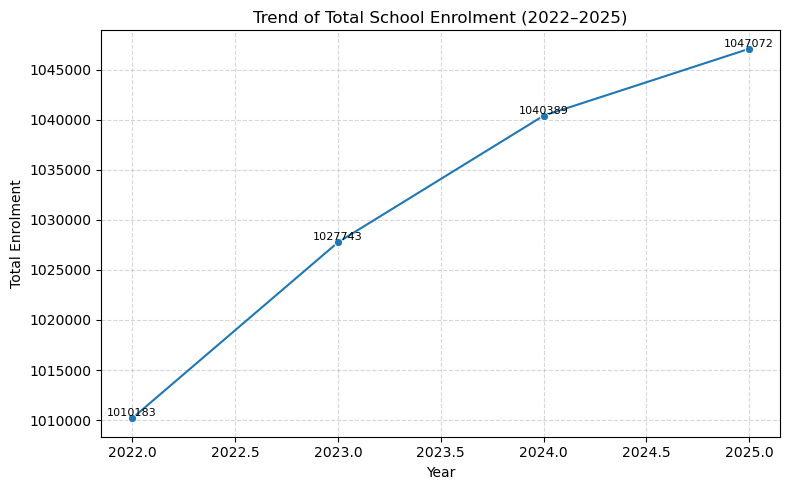

In [44]:
# Calculate trend data
trend = combined_df.groupby('Census_Year')['Grand_Total'].sum().reset_index()

plt.figure(figsize=(8, 5))

# Draw a line graph
sns.lineplot(
    data=trend,
    x='Census_Year',
    y='Grand_Total',
    marker='o'
)

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='y')

# Add data tags
for i, row in trend.iterrows():
    plt.text(
        row['Census_Year'],
        row['Grand_Total'],
        f"{int(row['Grand_Total'])}",
        ha='center',
        va='bottom',
        fontsize=8
    )

# More professional title
plt.title('Trend of Total School Enrolment (2022–2025)')
plt.xlabel('Year')
plt.ylabel('Total Enrolment')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The results indicate that total school enrolment across Victoria increased steadily between 2022 and 2025. Although the growth was gradual rather than rapid, the consistent upward trend suggests that educational demand continued to rise throughout the four-year period. This pattern reflects ongoing population growth and increasing pressure on educational infrastructure across the state.

### 2. Top 10 Schools by Average Enrolment

#### Purpose of the Analysis

This analysis compares enrolment patterns across Government, Catholic, and Independent schools over the four-year period.

#### Why This Analysis Was Conducted

Different education sectors often experience different growth patterns. Comparing sectors helps identify which sectors are expanding more rapidly and provides insight into changing educational preferences across Victoria.

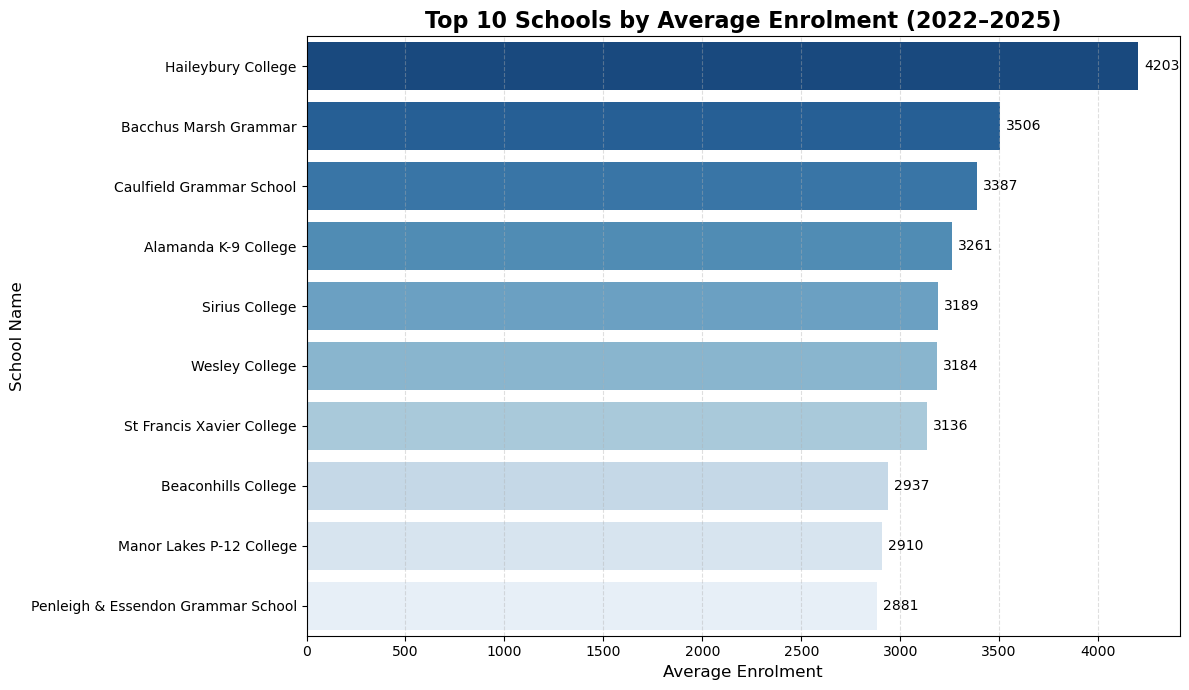

In [51]:
top10_schools = (
    combined_df.groupby('School_Name_enrol')['Grand_Total']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

colours = sns.color_palette("Blues_r", len(top10_schools))

ax = sns.barplot(
    data=top10_schools,
    x='Grand_Total',
    y='School_Name_enrol',
    palette=colours
)

for i, row in top10_schools.iterrows():
    ax.text(
        row['Grand_Total'] + 30,
        i,
        f"{int(row['Grand_Total'])}",
        va='center',
        fontsize=10
    )

plt.title(
    'Top 10 Schools by Average Enrolment (2022–2025)',
    fontsize=16,
    weight='bold'
)

plt.xlabel('Average Enrolment', fontsize=12)
plt.ylabel('School Name', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The bar chart presents the top 10 schools based on their average enrolment between 2022 and 2025. It can be observed that Haileybury College has the highest average enrolment, followed by Bacchus Marsh Grammar and Caulfield Grammar School.  
Overall, the results indicate that a small number of schools consistently maintain significantly higher enrolment levels compared to others. This suggests a concentration of students in certain large schools, which may be influenced by factors such as location, reputation, and available resources.

### 3. Total Enrolment by School Sector Over Time

#### Purpose of the Analysis

This analysis identifies schools with the highest average enrolment levels between 2022 and 2025.

#### Why This Analysis Was Conducted

Large enrolment levels may indicate schools with strong demand, large catchment areas, or significant regional importance. This analysis helps highlight major educational centres across Victoria.

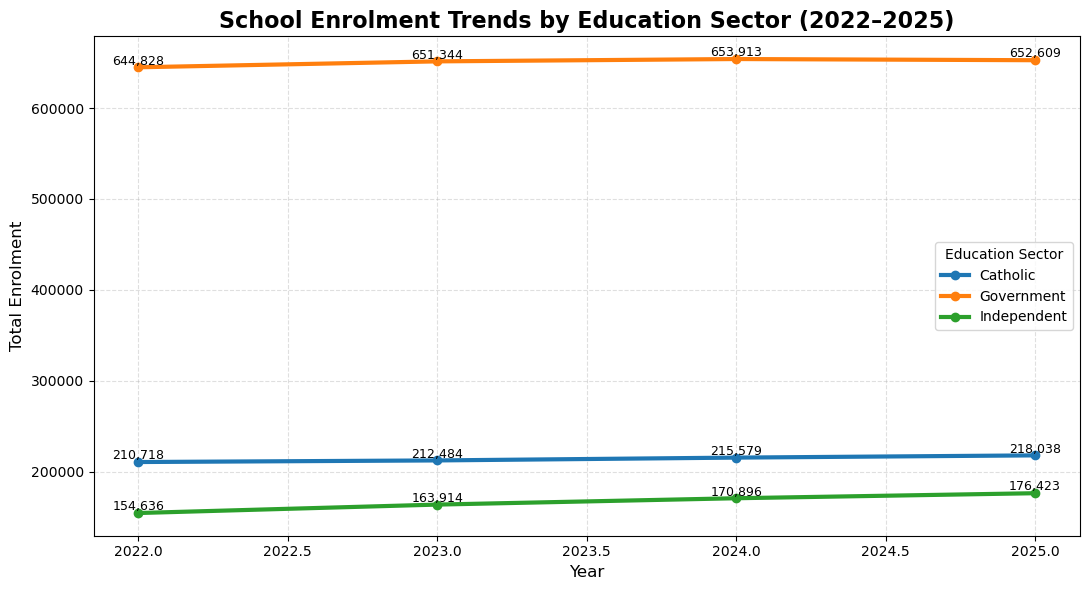

In [58]:
# Create sector trend table
sector_trend = (
    combined_df.groupby(['Census_Year', 'Education_Sector'])['Grand_Total']
    .sum()
    .reset_index()
)

# Convert long format to wide format
sector_trend = sector_trend.pivot(
    index='Census_Year',
    columns='Education_Sector',
    values='Grand_Total'
).reset_index()

# Plot
plt.figure(figsize=(11, 6))

plt.plot(
    sector_trend['Census_Year'],
    sector_trend['Catholic'],
    marker='o',
    linewidth=3,
    label='Catholic'
)

plt.plot(
    sector_trend['Census_Year'],
    sector_trend['Government'],
    marker='o',
    linewidth=3,
    label='Government'
)

plt.plot(
    sector_trend['Census_Year'],
    sector_trend['Independent'],
    marker='o',
    linewidth=3,
    label='Independent'
)

# Add value labels
for col in ['Catholic', 'Government', 'Independent']:
    for x, y in zip(sector_trend['Census_Year'], sector_trend[col]):
        plt.text(
            x,
            y + 3000,
            f"{int(y):,}",
            ha='center',
            fontsize=9
        )

plt.title(
    'School Enrolment Trends by Education Sector (2022–2025)',
    fontsize=16,
    weight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Enrolment', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Education Sector')

plt.tight_layout()
plt.show()

The line chart illustrates total school enrolment by sector from 2022 to 2025. It can be observed that government schools consistently have the highest enrolment across all years, significantly exceeding both Catholic and independent sectors.

All three sectors display a steady upward trend over the period. While government schools show stable growth with the largest share of enrolment, independent schools exhibit a slightly stronger rate of increase, and Catholic schools demonstrate moderate growth.

Overall, the results indicate that although enrolment is increasing across all sectors, the overall structure of the education system remains consistent, with government schools continuing to dominate.

### 4. Top 10 LGAs by Average Enrolment

#### Purpose of the Analysis

This analysis compares average enrolment levels across Victorian Local Government Areas (LGAs).

#### Why This Analysis Was Conducted

Regional comparison helps identify areas experiencing strong educational demand and population growth. The analysis also supports understanding of enrolment concentration across metropolitan and regional Victoria.

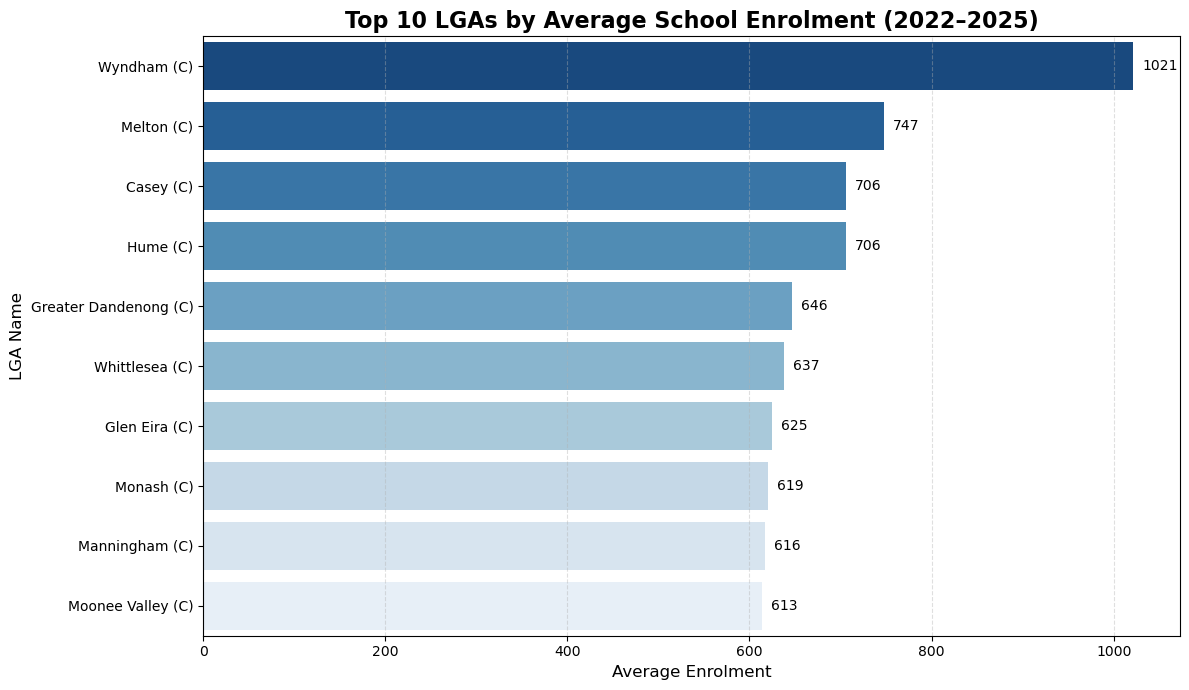

In [65]:
top10_lga = (
    combined_df.groupby('LGA_Name')['Grand_Total']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

# Colour gradient
colours = sns.color_palette("Blues_r", len(top10_lga))

ax = sns.barplot(
    data=top10_lga,
    x='Grand_Total',
    y='LGA_Name',
    palette=colours
)

# Add value labels
for i, row in top10_lga.iterrows():
    ax.text(
        row['Grand_Total'] + 10,
        i,
        f"{int(row['Grand_Total'])}",
        va='center',
        fontsize=10
    )

plt.title(
    'Top 10 LGAs by Average School Enrolment (2022–2025)',
    fontsize=16,
    weight='bold'
)

plt.xlabel('Average Enrolment', fontsize=12)
plt.ylabel('LGA Name', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

The bar chart presents the top 10 LGAs based on their average school enrolment between 2022 and 2025. It can be observed that Wyndham has the highest average enrolment, followed by Melton and Casey.

Overall, the results indicate that higher enrolment is concentrated in a small number of LGAs, suggesting that these regions have larger populations and a greater demand for education services. The relatively small differences among the remaining LGAs also indicate a consistent distribution of enrolment across major urban areas.

### 5. Heatmap of Enrolment by Year and Sector

#### Purpose of the Analysis

This heatmap visualises enrolment intensity across different education sectors and years.

#### Why This Analysis Was Conducted

Heatmaps provide a clearer visual comparison of enrolment distribution and make it easier to identify differences between sectors and overall enrolment patterns over time.

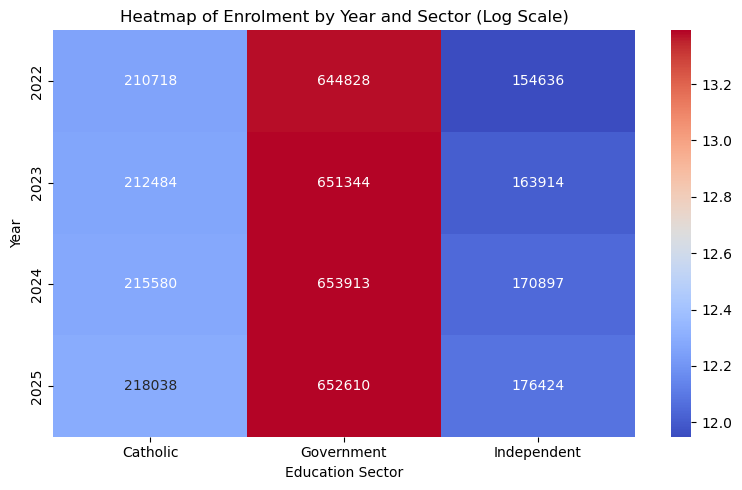

In [72]:
heatmap_data = combined_df.pivot_table(
    values='Grand_Total',
    index='Census_Year',
    columns='Education_Sector',
    aggfunc='sum'
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    np.log1p(heatmap_data),   
    annot=heatmap_data,       
    fmt='.0f',
    cmap='coolwarm'
)

plt.title('Heatmap of Enrolment by Year and Sector (Log Scale)')
plt.xlabel('Education Sector')
plt.ylabel('Year')

plt.tight_layout()
plt.show()

The heatmap presents total school enrolment by sector from 2022 to 2025 using a logarithmic scale to improve visual comparison across different magnitudes. It can be observed that government schools consistently exhibit the highest enrolment levels across all years, significantly exceeding both Catholic and independent sectors.

Despite the differences in scale, all sectors demonstrate a gradual increase in enrolment over time, with independent schools showing relatively stronger growth. The overall pattern remains consistent across the four years, indicating a stable structure in the education system alongside a steady rise in student numbers.

### 6.Enrolment Growth Rate Analysis (2022–2025)

#### Purpose of the Analysis

This analysis measures the percentage growth of school enrolment across Victorian LGAs between 2022 and 2025.

#### Why This Analysis Was Conducted

Growth rate analysis helps identify areas experiencing the fastest increases in educational demand. This is useful for future school planning, infrastructure development, and regional policy considerations.

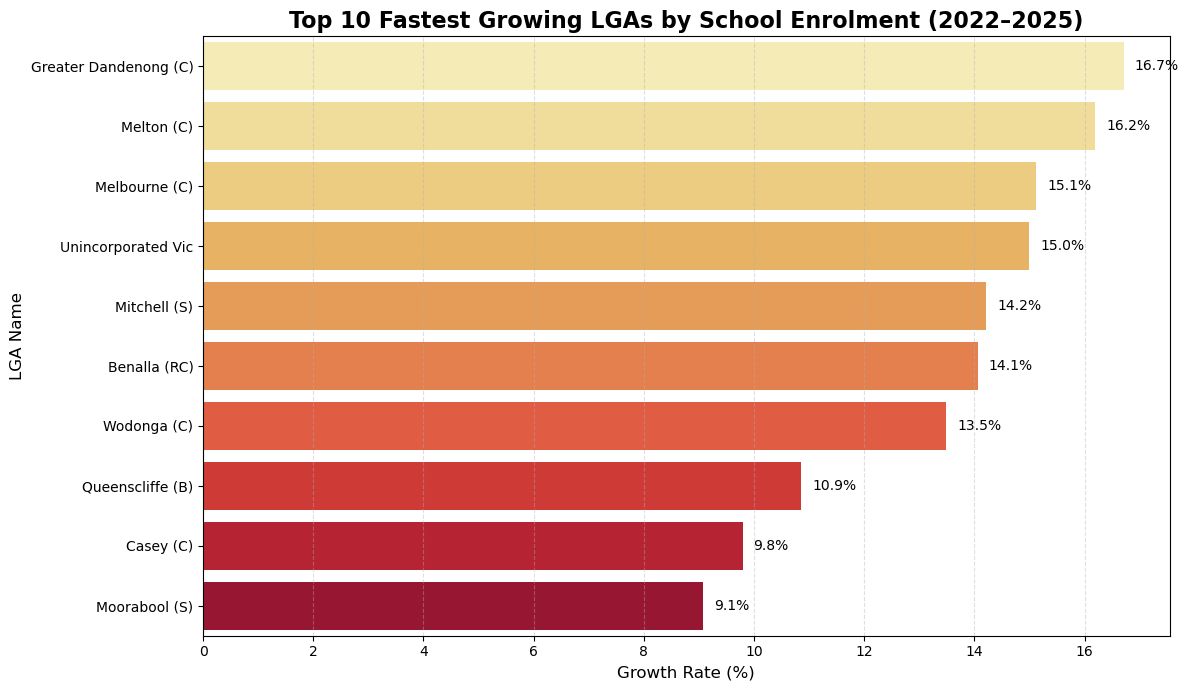

In [79]:
# Calculate total enrolment by LGA and year
lga_growth = (
    combined_df.groupby(['LGA_Name', 'Census_Year'])['Grand_Total']
    .sum()
    .reset_index()
)

# Convert years into columns
lga_growth_pivot = lga_growth.pivot(
    index='LGA_Name',
    columns='Census_Year',
    values='Grand_Total'
).fillna(0)

# Calculate growth rate from 2022 to 2025
lga_growth_pivot['Growth_Rate_%'] = (
    (lga_growth_pivot[2025] - lga_growth_pivot[2022])
    / lga_growth_pivot[2022]
) * 100

# Remove invalid values
lga_growth_pivot = lga_growth_pivot.replace([float('inf'), -float('inf')], pd.NA)
lga_growth_pivot = lga_growth_pivot.dropna(subset=['Growth_Rate_%'])

# Select top 10 fastest growing LGAs
top10_growth_lga = (
    lga_growth_pivot.sort_values('Growth_Rate_%', ascending=False)
    .head(10)
    .reset_index()
)

# Plot
plt.figure(figsize=(12, 7))

# Create colour palette
colours = sns.color_palette("YlOrRd", len(top10_growth_lga))

# Plot
ax = sns.barplot(
    data=top10_growth_lga,
    x='Growth_Rate_%',
    y='LGA_Name',
    palette=colours
)

# Add labels to bars
for i, row in top10_growth_lga.iterrows():
    ax.text(
        row['Growth_Rate_%'] + 0.2,
        i,
        f"{row['Growth_Rate_%']:.1f}%",
        va='center'
    )

# Titles and labels
plt.title(
    'Top 10 Fastest Growing LGAs by School Enrolment (2022–2025)',
    fontsize=16,
    weight='bold'
)

plt.xlabel('Growth Rate (%)', fontsize=12)
plt.ylabel('LGA Name', fontsize=12)

# Improve layout
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

The growth rate analysis identified several LGAs that experienced the most significant increases in school enrolment between 2022 and 2025. Greater Dandenong and Melton recorded the highest growth rates, suggesting rapidly increasing educational demand within Melbourne’s outer metropolitan areas. Several regional LGAs, including Benalla and Wodonga, also demonstrated notable enrolment growth, indicating that both metropolitan expansion and regional population changes are contributing to increased educational demand across Victoria.

## Interactive Map of School Enrolment Distribution

### Purpose of the Analysis

This analysis examines the geographic distribution of schools and enrolment concentrations across Victoria using interactive maps and spatial clustering.

### Why This Analysis Was Conducted

Spatial analysis helps identify major educational hubs and regional disparities in school distribution. Mapping enrolment patterns also improves understanding of geographic concentration and accessibility.

In [86]:
# Create map data
map_df = combined_df.copy()

# Keep only rows with valid coordinates
map_df = map_df.dropna(subset=['X', 'Y'])

# Use latest year for the map, for example 2025
map_df_2025 = map_df[map_df['Census_Year'] == 2025]

# Create base map centred on Victoria
m = folium.Map(
    location=[-37.5, 144.8],
    zoom_start=7,
    tiles='OpenStreetMap'
)

# Add marker cluster
marker_cluster = MarkerCluster().add_to(m)

# Add school markers
for _, row in map_df_2025.iterrows():
    popup_text = f"""
    <b>School:</b> {row['School_Name_enrol']}<br>
    <b>Sector:</b> {row['Education_Sector']}<br>
    <b>LGA:</b> {row['LGA_Name']}<br>
    <b>Enrolment:</b> {int(row['Grand_Total'])}<br>
    <b>Year:</b> {row['Census_Year']}
    """
    
    folium.CircleMarker(
        location=[row['Y'], row['X']],
        radius=max(3, min(row['Grand_Total'] / 300, 12)),
        popup=folium.Popup(popup_text, max_width=300),
        fill=True,
        fill_opacity=0.7
    ).add_to(marker_cluster)
m
# display(Image(filename='summary_map.png'))

The spatial clustering analysis highlights a strong concentration of schools and student enrolments within the Melbourne metropolitan region. The largest cluster is located in central Melbourne, indicating that this area contains the highest number of schools and the greatest overall enrolment levels across Victoria. This reflects the high population density and educational demand within metropolitan areas.

Several secondary clusters can also be identified in regional centres such as Geelong, Ballarat, Bendigo, Shepparton, and Traralgon. However, these clusters are significantly smaller than Melbourne, suggesting that educational resources and student populations are more dispersed in regional Victoria. The map also shows that remote areas contain relatively small clusters with lower enrolment levels, represented by smaller green markers. Overall, the spatial analysis demonstrates a clear imbalance in school distribution between metropolitan and regional areas across the state.

## Spatial Distribution of School Enrolment Clusters

### Purpose of the Analysis

This analysis uses Principal Component Analysis (PCA) and clustering techniques to group LGAs based on similar enrolment patterns.

### Why This Analysis Was Conducted

Clustering helps simplify large datasets by identifying groups with similar characteristics. This allows clearer interpretation of enrolment similarities and differences between metropolitan and regional areas.

In [93]:
# Use latest year data, for example 2025
map_df = combined_df[combined_df['Census_Year'] == 2025].copy()

# Remove rows with missing coordinates
map_df = map_df.dropna(subset=['X', 'Y'])

# Ensure coordinates are numeric
map_df['X'] = pd.to_numeric(map_df['X'], errors='coerce')
map_df['Y'] = pd.to_numeric(map_df['Y'], errors='coerce')

map_df = map_df.dropna(subset=['X', 'Y'])

# Prepare coordinates
coords = map_df[['Y', 'X']]   # Y = latitude, X = longitude

# Standardise coordinates
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# Apply DBSCAN
dbscan = DBSCAN(
    eps=0.08,
    min_samples=5
)

map_df['Spatial_Cluster'] = dbscan.fit_predict(coords_scaled)

# Check cluster counts
print(map_df['Spatial_Cluster'].value_counts())

# Summarise each spatial cluster
cluster_summary = (
    map_df[map_df['Spatial_Cluster'] != -1]
    .groupby('Spatial_Cluster')
    .agg(
        School_Count=('Grand_Total', 'count'),
        Avg_Enrolment=('Grand_Total', 'mean'),
        Total_Enrolment=('Grand_Total', 'sum'),
        Centre_Lat=('Y', 'mean'),
        Centre_Lon=('X', 'mean')
    )
    .reset_index()
)

# Create base map
m_summary = folium.Map(
    location=[-37.8, 144.9],
    zoom_start=7,
    tiles='OpenStreetMap'
)

# Define enrolment level colours
def get_colour(total_enrolment):
    if total_enrolment < 50000:
        return 'green'
    elif total_enrolment < 150000:
        return 'orange'
    else:
        return 'red'

# Add cluster markers
for _, row in cluster_summary.iterrows():

    colour = get_colour(row['Total_Enrolment'])

    popup_text = f"""
    <b>Spatial Cluster:</b> {row['Spatial_Cluster']}<br>
    <b>Number of Schools:</b> {int(row['School_Count'])}<br>
    <b>Total Enrolment:</b> {int(row['Total_Enrolment'])}<br>
    <b>Average Enrolment:</b> {int(row['Avg_Enrolment'])}
    """

    folium.CircleMarker(
        location=[row['Centre_Lat'], row['Centre_Lon']],
        
        # Circle size based on school count
        radius=max(8, min(row['School_Count'] / 5, 35)),

        popup=folium.Popup(popup_text, max_width=300),

        color=colour,
        fill=True,
        fill_color=colour,
        fill_opacity=0.7
    ).add_to(m_summary)

# Display map
m_summary
# display(Image(filename='cluster_map.png'))

Spatial_Cluster
 0     1286
-1      424
 2       90
 4       53
 3       43
 15      32
 7       28
 5       26
 20      23
 11      16
 14      16
 13      13
 17      12
 10      12
 25      10
 23      10
 6       10
 1       10
 16      10
 12       9
 9        9
 8        9
 19       7
 21       7
 22       7
 24       7
 32       7
 26       6
 33       6
 28       6
 29       6
 31       5
 34       5
 18       5
 30       5
 27       5
 35       5
 36       5
Name: count, dtype: int64


The refined spatial clustering map provides a clearer overview of the distribution of school enrolment clusters across Victoria. Melbourne remains the dominant educational hub, represented by the large red cluster in the centre of the map. This indicates that the metropolitan region contains the highest concentration of schools and the largest overall student enrolment levels in the state. The significantly larger marker size further demonstrates the strong demand for educational services within metropolitan Melbourne.

Regional centres such as Geelong, Ballarat, Bendigo, Shepparton, and Traralgon also form identifiable clusters, although these are considerably smaller than Melbourne. Most regional areas are represented by green markers, suggesting lower enrolment levels and a more dispersed school distribution. The analysis highlights the imbalance between metropolitan and regional education distribution, showing that schools and student populations are heavily concentrated around Melbourne while rural areas contain smaller and more isolated educational clusters.

## Forecasting Future School Enrolment Trends (2026–2028)

### Purpose of the Analysis

This analysis predicts future school enrolment trends from 2026 to 2028 using historical enrolment data.

### Why This Analysis Was Conducted

Forecasting supports long-term educational planning by estimating future enrolment demand. The analysis helps identify whether additional educational infrastructure and resources may be required in future years.

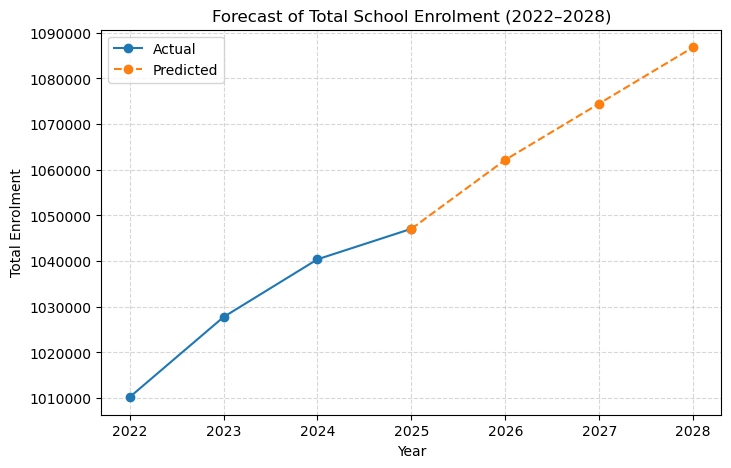

2026: 1062175
2027: 1074506
2028: 1086838


In [100]:
# Prepare data
trend = combined_df.groupby('Census_Year')['Grand_Total'].sum().reset_index()

X = trend[['Census_Year']]
y = trend['Grand_Total']

# Building a Model
model = LinearRegression()
model.fit(X, y)

# Predicting future years
future_years = np.array([2026, 2027, 2028]).reshape(-1, 1)
predictions = model.predict(future_years)

# Merge data for plotting
all_years = np.concatenate([trend['Census_Year'], future_years.flatten()])
all_values = np.concatenate([y, predictions])

# Drawing
plt.figure(figsize=(8, 5))

# Actual line
plt.plot(
    trend['Census_Year'],
    y,
    marker='o',
    label='Actual'
)

# Connect predicted line from 2025
extended_years = np.concatenate([[trend['Census_Year'].iloc[-1]], future_years.flatten()])
extended_values = np.concatenate([[y.iloc[-1]], predictions])

plt.plot(
    extended_years,
    extended_values,
    marker='o',
    linestyle='--',
    label='Predicted'
)

plt.ticklabel_format(style='plain', axis='y')

plt.title('Forecast of Total School Enrolment (2022–2028)')
plt.xlabel('Year')
plt.ylabel('Total Enrolment')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Print predicted values
for year, pred in zip(future_years.flatten(), predictions):
    print(f"{year}: {int(pred)}")

The forecasting analysis suggests that total school enrolment across Victoria is likely to continue increasing over the next several years. Predicted enrolment figures for 2026 to 2028 indicate a continuation of the upward trend observed between 2022 and 2025. Although the forecast is based on historical trends and should not be interpreted as a certainty, the results suggest ongoing growth in educational demand and the potential need for continued expansion of school infrastructure and resources across the state.

# Conclusion and Future Recommendations

The analysis of school enrolment data from 2022 to 2025 provides valuable insights into enrolment trends, regional distribution, and educational growth patterns across Victoria. The results show that total school enrolment has steadily increased over the four-year period, with Government schools maintaining the largest share of student enrolments.

Regional analysis revealed that Melbourne remains the dominant educational hub, while several outer metropolitan and regional LGAs, including Greater Dandenong, Melton, and Geelong, experienced significant enrolment growth. The clustering and spatial analyses further highlighted the uneven geographic distribution of schools and student populations across the state.

The future prediction model also suggests that school enrolment levels are likely to continue increasing in the coming years, indicating ongoing demand for educational infrastructure and services. Overall, the project demonstrates how data analytics, clustering techniques, spatial analysis, and forecasting methods can be combined to support educational planning and decision-making.

For future improvements, additional demographic and population datasets could be integrated to further investigate the relationship between population growth and school enrolment demand. More advanced predictive models and interactive dashboard features could also be developed to provide deeper analytical insights and improve user interaction.